# Chess Scoresheet Cell Extractor - Kaggle Pipeline Demo

Notebook này tái hiện pipeline hiện tại của repo `chess-scoresheet-cell-extractor` trên Kaggle.

Mục tiêu:

- Clone code và dữ liệu input trực tiếp từ GitHub, không dùng dữ liệu upload thủ công trong `/kaggle/input`.
- Chọn một ảnh scoresheet trong `inputs/` để minh họa từng bước xử lý.
- Chạy lại pipeline đầy đủ để sinh crop cell vào thư mục output của notebook.

Trên Kaggle, cần bật `Internet` trong phần notebook settings trước khi chạy cell clone repo.

## 1. Clone repo hiện tại từ GitHub

Cell này tải toàn bộ code, `requirements.txt`, ảnh `inputs/` và output mẫu đã được commit lên GitHub. Notebook không yêu cầu upload input mới lên Kaggle.

In [1]:
from pathlib import Path
import subprocess
import sys

REPO_URL = 'https://github.com/toanthangO20/chess-scoresheet-cell-extractor.git'
REPO_NAME = 'chess-scoresheet-cell-extractor'

WORK_DIR = Path('/kaggle/working')
if not WORK_DIR.exists():
    WORK_DIR = Path.cwd() / '_kaggle_working'

WORK_DIR.mkdir(parents=True, exist_ok=True)
REPO_DIR = WORK_DIR / REPO_NAME

if (REPO_DIR / '.git').exists():
    print(f'Repo already exists: {REPO_DIR}')
    subprocess.run(['git', '-C', str(REPO_DIR), 'pull', '--ff-only'], check=True)
elif REPO_DIR.exists():
    raise RuntimeError(f'{REPO_DIR} exists but is not a git repository. Remove it or choose another folder.')
else:
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, str(REPO_DIR)], check=True)

commit = subprocess.check_output(
    ['git', '-C', str(REPO_DIR), 'rev-parse', '--short', 'HEAD'],
    text=True,
).strip()

print(f'Repository: {REPO_DIR}')
print(f'Commit: {commit}')

Cloning into '/kaggle/working/chess-scoresheet-cell-extractor'...


Repository: /kaggle/working/chess-scoresheet-cell-extractor
Commit: eed5651


## 2. Cài dependency và import pipeline

Pipeline chính nằm trong `extract_cells.py`. Notebook import trực tiếp các hàm từ file này để phần demo bám đúng implementation hiện tại.

In [2]:
import importlib
import math
import shutil

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', '-r', str(REPO_DIR / 'requirements.txt')],
    check=True,
)

sys.path.insert(0, str(REPO_DIR))

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import extract_cells as pipeline

pipeline = importlib.reload(pipeline)
plt.rcParams['figure.dpi'] = 120

def show_image(ax, image_data, title, cmap=None):
    ax.imshow(image_data, cmap=cmap)
    ax.set_title(title, fontsize=10)
    ax.axis('off')


def show_cell_gallery(cell_items, cols=4, max_items=16):
    selected = cell_items[:max_items]
    if not selected:
        print('No cells to show')
        return

    rows = math.ceil(len(selected) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 1.8))
    axes = np.array(axes).reshape(-1)

    for ax, item in zip(axes, selected):
        ax.imshow(item['image'], cmap='gray')
        ax.set_title(item['file_name'], fontsize=7)
        ax.axis('off')

    for ax in axes[len(selected):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


print(f'OpenCV: {cv2.__version__}')
print(f'NumPy: {np.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 84.1 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.


OpenCV: 4.13.0
NumPy: 2.0.2


## 3. Chọn một ảnh input để demo

Notebook dùng ảnh `012_0.png` trong repo làm ảnh minh họa. Đây là một scoresheet có đủ grid rõ để demo các bước: threshold, tách đường kẻ, tìm contour, sort cell, crop cell và lọc ô có chữ viết tay.

Input images:
- 001_0.png
- 009_0.png
- 011_0.png
- 012_0.png
Demo image: /kaggle/working/chess-scoresheet-cell-extractor/inputs/012_0.png
Size: 1400 x 1729


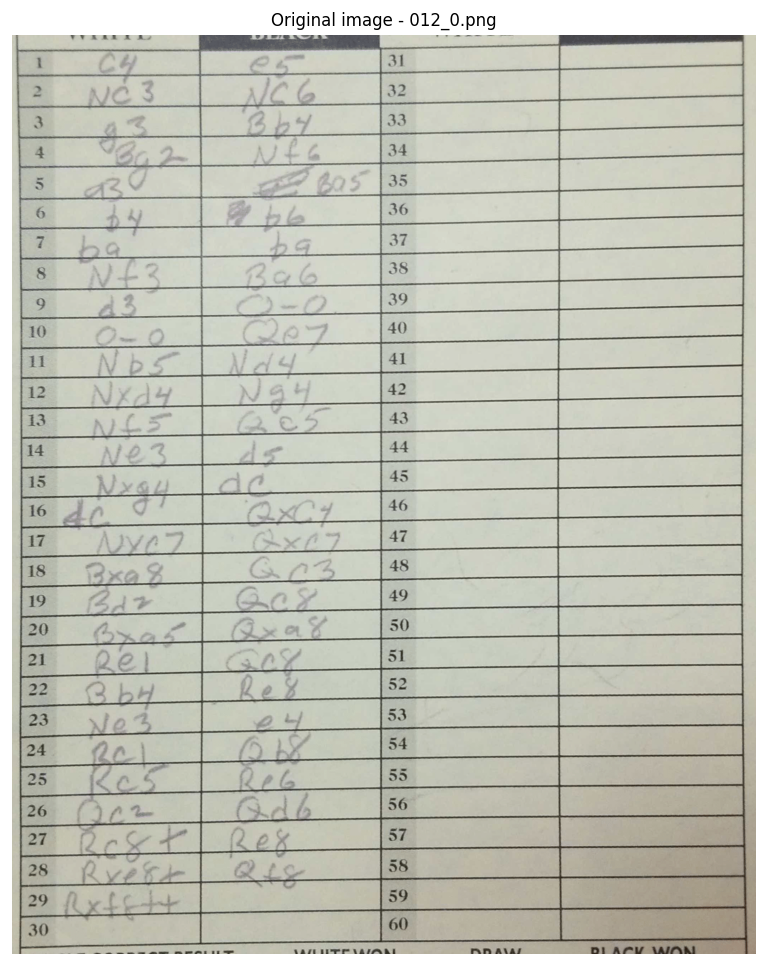

In [3]:
INPUT_DIR = REPO_DIR / 'inputs'
COMMITTED_OUTPUT_DIR = REPO_DIR / 'outputs'

input_images = sorted(INPUT_DIR.glob('*.png')) + sorted(INPUT_DIR.glob('*.jpg')) + sorted(INPUT_DIR.glob('*.jpeg'))
print('Input images:')
for path in input_images:
    print(f'- {path.name}')

DEMO_IMAGE_NAME = '012_0.png'
demo_path = INPUT_DIR / DEMO_IMAGE_NAME
if not demo_path.exists():
    raise FileNotFoundError(f'Demo image not found: {demo_path}')

image = Image.open(demo_path).convert('RGB')
print(f'Demo image: {demo_path}')
print(f'Size: {image.width} x {image.height}')

fig, ax = plt.subplots(figsize=(8, 10))
show_image(ax, np.array(image), f'Original image - {DEMO_IMAGE_NAME}')
plt.show()

## 4. Chuyển sang grayscale và nhị phân hóa bằng Otsu

Pipeline không OCR trực tiếp trên ảnh gốc. Đầu tiên ảnh được chuyển sang grayscale, sau đó dùng Otsu threshold để tách vùng sáng/tối. Ảnh nhị phân này là đầu vào cho bước tìm đường kẻ bảng.

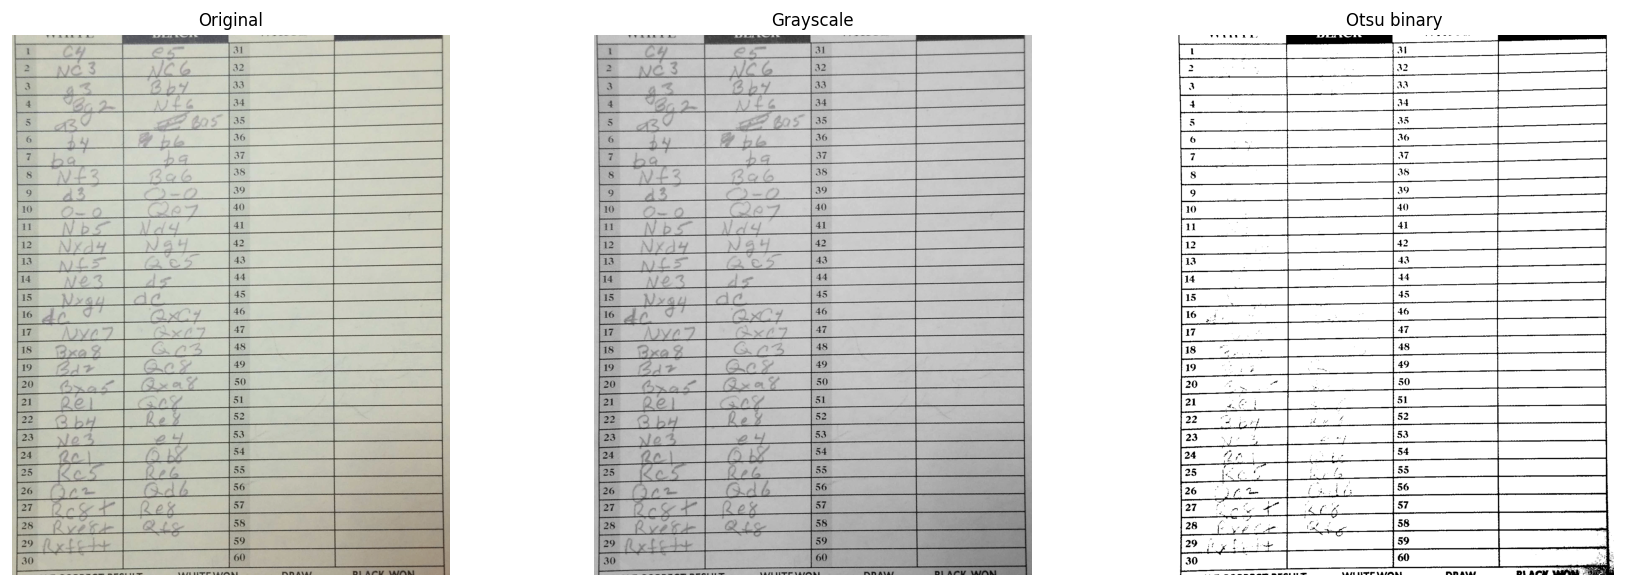

In [4]:
gray_image = image.convert('L')
binary_image = pipeline.image_to_binary(gray_image)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
show_image(axes[0], np.array(image), 'Original')
show_image(axes[1], np.array(gray_image), 'Grayscale', cmap='gray')
show_image(axes[2], binary_image, 'Otsu binary', cmap='gray')
plt.tight_layout()
plt.show()

## 5. Tách đường kẻ ngang/dọc của bảng

Từ ảnh nhị phân, pipeline đảo màu rồi dùng morphology với kernel ngang và dọc. Kết quả là mask chứa các đường grid chính của scoresheet.

In [ ]:
inverted_binary = cv2.bitwise_not(binary_image)

horizontal_kernel_length = max(1, inverted_binary.shape[1] // 40)
vertical_kernel_length = max(1, inverted_binary.shape[0] // 40)

horizontal_kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT, (horizontal_kernel_length, 1)
)
vertical_kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT, (1, vertical_kernel_length)
)

horizontal_lines = cv2.erode(inverted_binary, horizontal_kernel, iterations=1)
horizontal_lines = cv2.dilate(horizontal_lines, horizontal_kernel, iterations=1)

vertical_lines = cv2.erode(inverted_binary, vertical_kernel, iterations=1)
vertical_lines = cv2.dilate(vertical_lines, vertical_kernel, iterations=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
show_image(axes[0], horizontal_lines, 'Horizontal lines only', cmap='gray')
show_image(axes[1], vertical_lines, 'Vertical lines only', cmap='gray')
plt.tight_layout()
plt.show()

In [ ]:
grid_lines = cv2.add(horizontal_lines, vertical_lines)

grid_overlay = np.array(image).copy()
grid_overlay[grid_lines > 0] = [255, 0, 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
show_image(axes[0], binary_image, 'Binary input', cmap='gray')
show_image(axes[1], grid_lines, 'Detected grid lines', cmap='gray')
show_image(axes[2], grid_overlay, 'Grid overlay on original')
plt.tight_layout()
plt.show()

## 6. Tìm contour ô và sắp xếp theo thứ tự scoresheet

Pipeline tìm contour hình tứ giác từ grid mask, lọc theo diện tích gần median để loại nhiễu, sau đó gán cột và hàng. Thứ tự output là nửa trái trước, nửa phải sau; trong mỗi nước đi, ô White đứng trước ô Black.

Raw rectangle contours: 120
Sorted move cells: 120


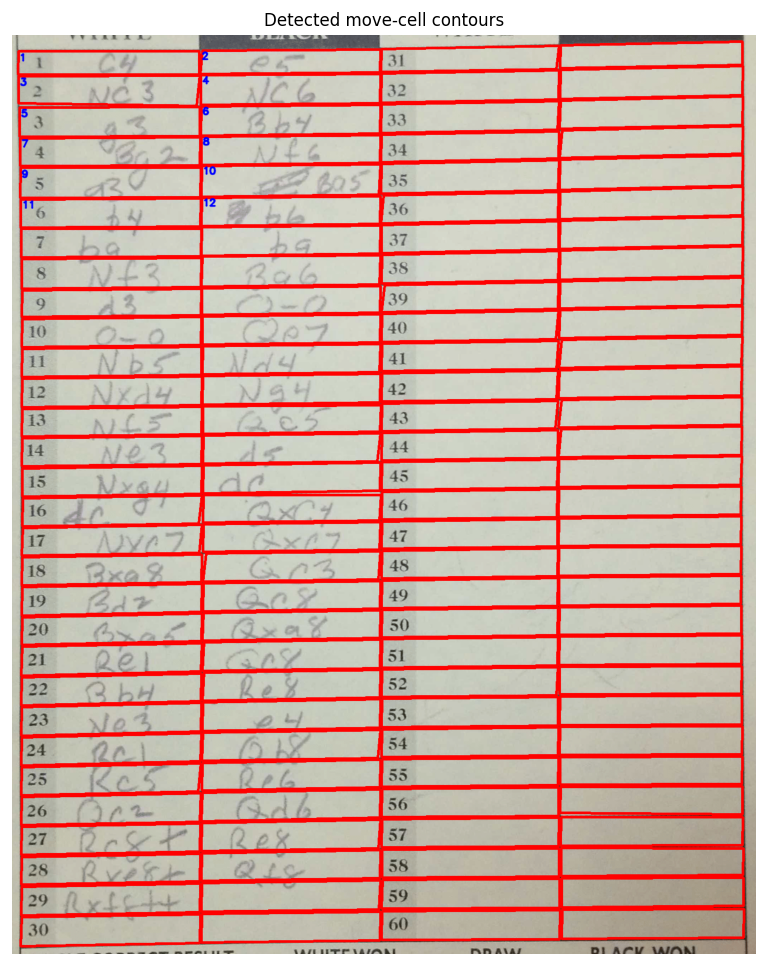

In [6]:
contours = pipeline.find_move_cell_contours(grid_lines)
cells = pipeline.sort_cells_by_scoresheet_move_order(contours)

contour_overlay = np.array(image).copy()
for index, cell_info in enumerate(cells):
    contour = np.asarray(cell_info['contour'], dtype=np.int32).reshape((-1, 1, 2))
    cv2.polylines(contour_overlay, [contour], True, (255, 0, 0), 3)
    if index < 12:
        x_min, y_min, _, _ = pipeline.contour_bounds(cell_info['contour'])
        cv2.putText(
            contour_overlay,
            str(index + 1),
            (x_min + 3, y_min + 18),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 0, 255),
            2,
            cv2.LINE_AA,
        )

print(f'Raw rectangle contours: {len(contours)}')
print(f'Sorted move cells: {len(cells)}')

fig, ax = plt.subplots(figsize=(8, 10))
show_image(ax, contour_overlay, 'Detected move-cell contours')
plt.show()

## 7. Crop từng ô với padding và bỏ number column

Mỗi contour được crop thành ảnh cell riêng. Pipeline mặc định lấy thêm padding phía trên và dưới (`--cell-top-padding-ratio 0.15`, `--cell-bottom-padding-ratio 0.25`) để giữ chữ viết tay khi nét chữ đè lên dòng kẻ. Với cột White, pipeline tiếp tục cắt phần số nước đi bên trái (`--trim-number-column-ratio 0.28`).

Cropped cells: 120


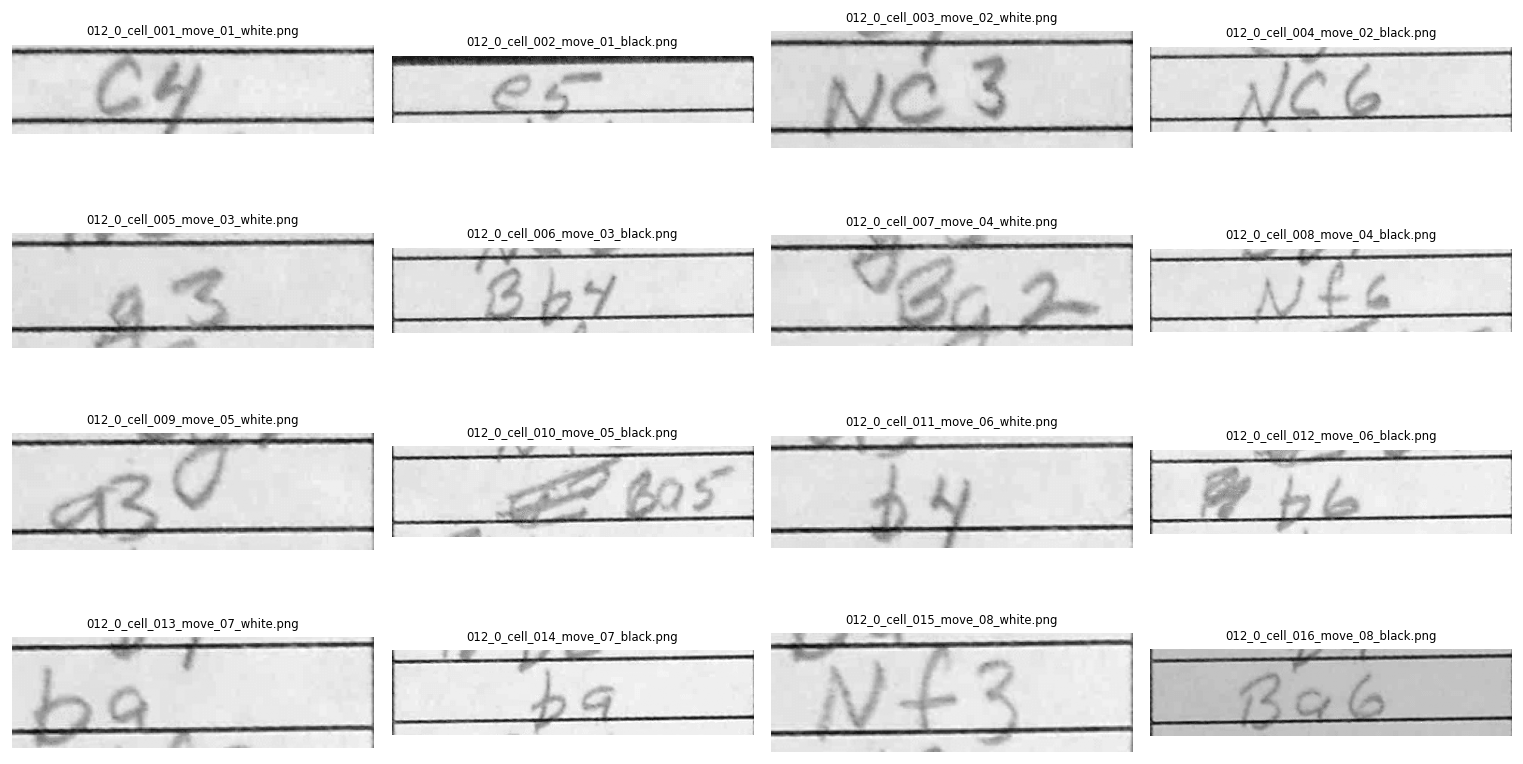

In [7]:
CELL_TOP_PADDING_RATIO = 0.15
CELL_BOTTOM_PADDING_RATIO = 0.25
TRIM_NUMBER_COLUMN_RATIO = 0.28
MIN_DARK_RATIO = 0.012

cropped_cells = []
for index, cell_info in enumerate(cells):
    cell_image = pipeline.crop_cell(
        gray_image=gray_image,
        contour=cell_info['contour'],
        top_padding_ratio=CELL_TOP_PADDING_RATIO,
        bottom_padding_ratio=CELL_BOTTOM_PADDING_RATIO,
    )
    cell_image = pipeline.trim_printed_move_number_column(
        image=cell_image,
        column=cell_info['column'],
        trim_ratio=TRIM_NUMBER_COLUMN_RATIO,
    )
    cropped_cells.append(
        {
            'index': index,
            'file_name': pipeline.move_cell_name(demo_path.stem, index, len(cells)),
            'image': cell_image,
            'info': cell_info,
        }
    )

print(f'Cropped cells: {len(cropped_cells)}')
show_cell_gallery(cropped_cells, cols=4, max_items=16)

In [ ]:
if not cropped_cells:
    raise RuntimeError('No cropped cells to show')

example_crop = next(
    (item for item in cropped_cells if item['info'].get('column') in (1, 3)),
    cropped_cells[0],
)
example_info = example_crop['info']
example_contour = np.asarray(example_info['contour'], dtype=np.int32).reshape((-1, 1, 2))
x_min, y_min, x_max, y_max = pipeline.contour_bounds(example_info['contour'])
cell_width = x_max - x_min
cell_height = y_max - y_min

crop_left = max(0, x_min)
crop_top = max(0, y_min - int(cell_height * CELL_TOP_PADDING_RATIO))
crop_right = min(image.width, x_max)
crop_bottom = min(image.height, y_max + int(cell_height * CELL_BOTTOM_PADDING_RATIO))

before_crop_overlay = np.array(image).copy()
cv2.rectangle(
    before_crop_overlay,
    (crop_left, crop_top),
    (crop_right, crop_bottom),
    (255, 0, 0),
    4,
)
cv2.polylines(before_crop_overlay, [example_contour], True, (0, 0, 255), 3)

zoom_margin_x = int(cell_width * 0.6)
zoom_margin_y = int(cell_height * 1.2)
zoom_left = max(0, crop_left - zoom_margin_x)
zoom_top = max(0, crop_top - zoom_margin_y)
zoom_right = min(image.width, crop_right + zoom_margin_x)
zoom_bottom = min(image.height, crop_bottom + zoom_margin_y)
before_crop_zoom = before_crop_overlay[zoom_top:zoom_bottom, zoom_left:zoom_right]

after_crop = np.array(example_crop['image'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
show_image(axes[0], before_crop_zoom, f"Before crop - {example_crop['file_name']}")
show_image(axes[1], after_crop, f"After crop - {example_crop['file_name']}", cmap='gray')
plt.tight_layout()
plt.show()

## 8. Lọc ô có chữ viết tay bằng tương phản nét mực

Bộ lọc `--non-empty-only` không còn đếm pixel tối tuyệt đối. Thay vào đó, pipeline ước lượng nền giấy cục bộ, lấy phần pixel tối hơn nền đủ mạnh, loại đường kẻ dài khỏi mask và loại cụm nhiễu nhỏ. Vì crop vẫn giữ dòng kẻ trên/dưới, bước này giúp bỏ các ô chỉ có dòng kẻ nhưng vẫn giữ ô có chữ viết tay đè lên dòng kẻ.

Cells kept by --non-empty-only: 59
Cells rejected as blank/noise: 61


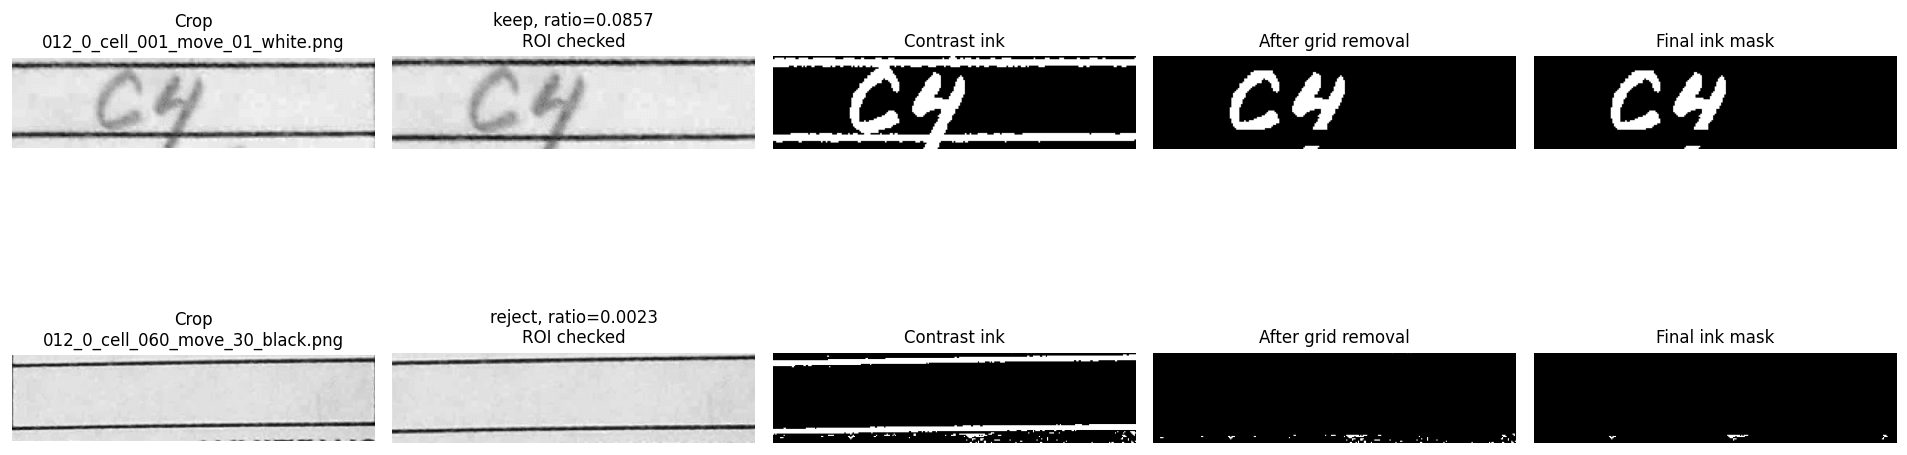

In [8]:
def handwriting_debug(cell_image, min_dark_ratio=MIN_DARK_RATIO):
    gray = np.array(cell_image.convert('L'))
    height, width = gray.shape

    top = int(height * 0.02)
    bottom = int(height * 0.98)
    left = int(width * 0.04)
    right = int(width * 0.96)
    roi = gray[top:bottom, left:right]

    contrast_ink = pipeline.contrast_ink_pixels(roi)
    without_grid = pipeline.remove_grid_line_pixels(contrast_ink)
    final_ink = pipeline.remove_small_ink_components(without_grid)
    ink_ratio = float(np.mean(final_ink > 0)) if final_ink.size else 0.0

    return {
        'roi': roi,
        'contrast_ink': contrast_ink,
        'without_grid': without_grid,
        'final_ink': final_ink,
        'ink_ratio': ink_ratio,
        'keep': ink_ratio >= min_dark_ratio,
    }


for item in cropped_cells:
    debug = handwriting_debug(item['image'])
    item['debug'] = debug
    item['ink_ratio'] = debug['ink_ratio']
    item['keep'] = debug['keep']

kept_cells = [item for item in cropped_cells if item['keep']]
rejected_cells = [item for item in cropped_cells if not item['keep']]

print(f'Cells kept by --non-empty-only: {len(kept_cells)}')
print(f'Cells rejected as blank/noise: {len(rejected_cells)}')

examples = []
if kept_cells:
    examples.append(kept_cells[0])
if rejected_cells:
    examples.append(rejected_cells[0])

fig, axes = plt.subplots(len(examples), 5, figsize=(16, 3.2 * len(examples)))
axes = np.array(axes).reshape(len(examples), 5)

for row, item in enumerate(examples):
    debug = item['debug']
    state = 'keep' if item['keep'] else 'reject'
    title_prefix = f"{state}, ratio={item['ink_ratio']:.4f}"

    show_image(axes[row, 0], item['image'], f"Crop\n{item['file_name']}", cmap='gray')
    show_image(axes[row, 1], debug['roi'], f'{title_prefix}\nROI checked', cmap='gray')
    show_image(axes[row, 2], debug['contrast_ink'], 'Contrast ink', cmap='gray')
    show_image(axes[row, 3], debug['without_grid'], 'After grid removal', cmap='gray')
    show_image(axes[row, 4], debug['final_ink'], 'Final ink mask', cmap='gray')

plt.tight_layout()
plt.show()

## 9. Lưu kết quả cho ảnh demo bằng chính hàm pipeline

Cell này gọi `extract_cells_from_image` giống script chính, bật `non_empty_only=True`, rồi hiển thị một số crop đã được lưu.

Saved cells for 012_0.png: 59
Demo output directory: /kaggle/working/demo_pipeline_output/012_0


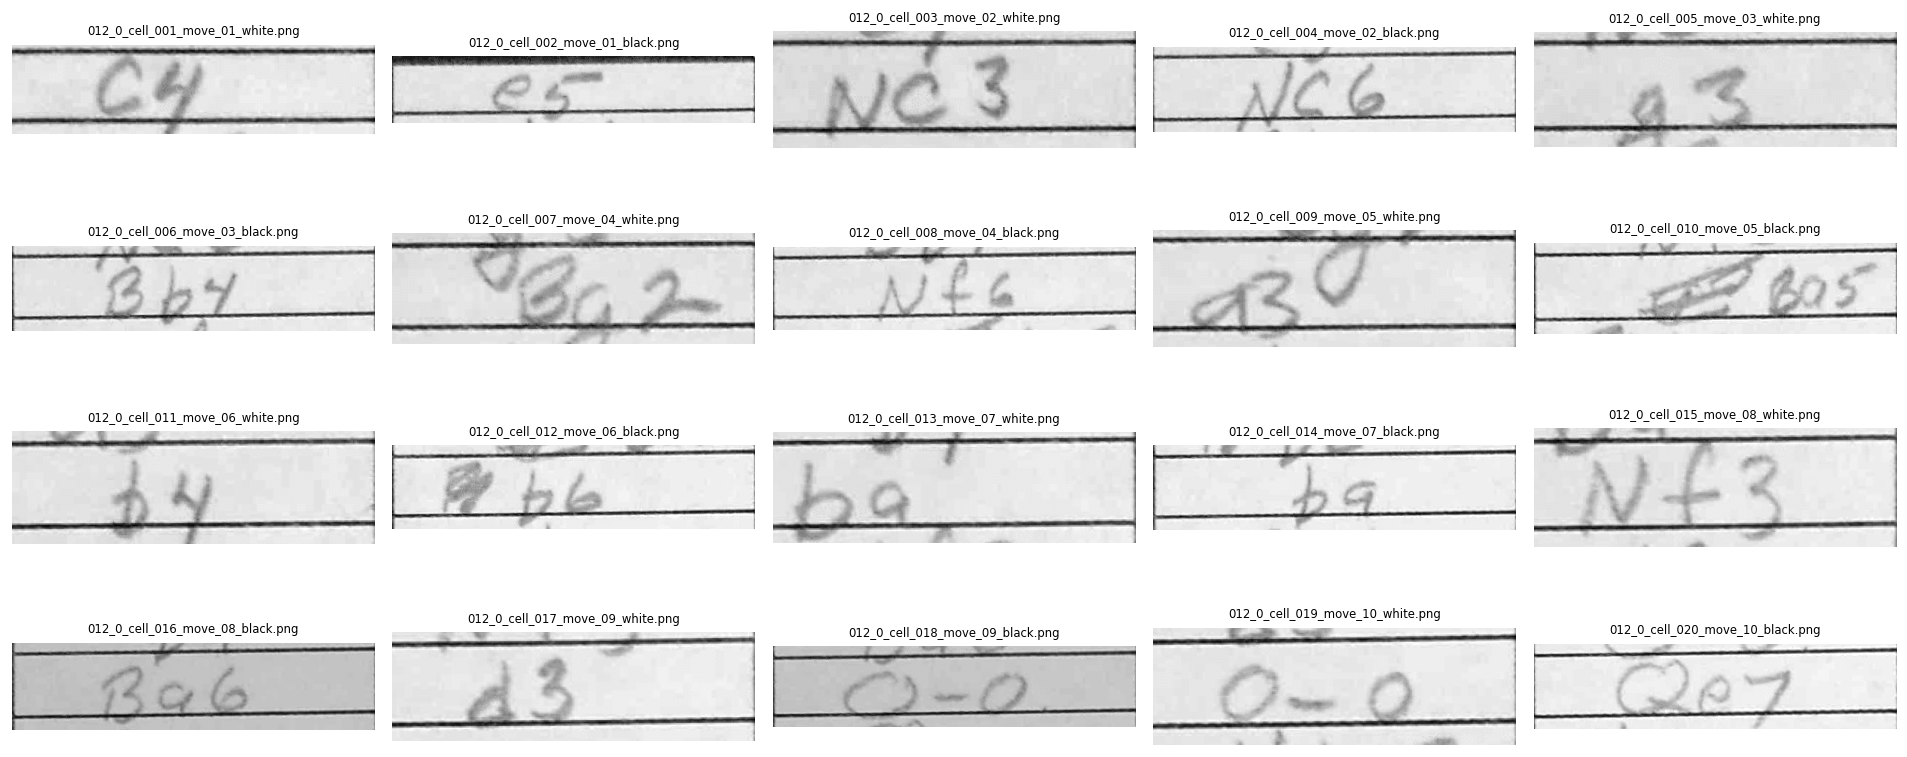

In [9]:
DEMO_OUTPUT_DIR = WORK_DIR / 'demo_pipeline_output'
if DEMO_OUTPUT_DIR.exists():
    shutil.rmtree(DEMO_OUTPUT_DIR)

saved_count = pipeline.extract_cells_from_image(
    image_path=demo_path,
    output_dir=DEMO_OUTPUT_DIR,
    non_empty_only=True,
    min_dark_ratio=MIN_DARK_RATIO,
    trim_number_column_ratio=TRIM_NUMBER_COLUMN_RATIO,
    cell_top_padding_ratio=CELL_TOP_PADDING_RATIO,
    cell_bottom_padding_ratio=CELL_BOTTOM_PADDING_RATIO,
    save_debug=True,
)

demo_generated_files = sorted((DEMO_OUTPUT_DIR / demo_path.stem).glob('*.png'))
print(f'Saved cells for {DEMO_IMAGE_NAME}: {saved_count}')
print(f'Demo output directory: {DEMO_OUTPUT_DIR / demo_path.stem}')

generated_items = [
    {'file_name': path.name, 'image': Image.open(path).convert('L')}
    for path in demo_generated_files
]
show_cell_gallery(generated_items, cols=5, max_items=20)

## 10. Chạy pipeline đầy đủ cho toàn bộ thư mục `inputs/`

Cell cuối chạy command-line script giống cách dùng thật của project. Output được ghi vào `/kaggle/working/full_pipeline_output` để có thể tải về từ Kaggle notebook output.

In [10]:
FULL_OUTPUT_DIR = WORK_DIR / 'full_pipeline_output'
if FULL_OUTPUT_DIR.exists():
    shutil.rmtree(FULL_OUTPUT_DIR)

command = [
    sys.executable,
    str(REPO_DIR / 'extract_cells.py'),
    '--input-dir',
    str(REPO_DIR / 'inputs'),
    '--output-dir',
    str(FULL_OUTPUT_DIR),
    '--non-empty-only',
]

print('Running command:')
print(' '.join(command))
subprocess.run(command, check=True)

full_outputs = sorted(FULL_OUTPUT_DIR.glob('**/*.png'))
print(f'Generated PNG files: {len(full_outputs)}')
print(f'Full output directory: {FULL_OUTPUT_DIR}')

Running command:
/usr/bin/python3 /kaggle/working/chess-scoresheet-cell-extractor/extract_cells.py --input-dir /kaggle/working/chess-scoresheet-cell-extractor/inputs --output-dir /kaggle/working/full_pipeline_output --non-empty-only


INFO - Detected 117 move-cell contours in 001_0.png
INFO - Saved 64 cells for 001_0.png
INFO - Detected 112 move-cell contours in 009_0.png
INFO - Saved 80 cells for 009_0.png
INFO - Detected 97 move-cell contours in 011_0.png
INFO - Saved 89 cells for 011_0.png
INFO - Detected 120 move-cell contours in 012_0.png


Generated PNG files: 290
Full output directory: /kaggle/working/full_pipeline_output


INFO - Saved 57 cells for 012_0.png
INFO - Done. Saved 290 cells to /kaggle/working/full_pipeline_output
